<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/Linear-Regression-Models/TSLA_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_29195/3404417012.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("TSLA", start="2012-01-01")
[*********************100%***********************]  1 of 1 completed


Linear Regression Performance (TSLA)
MAE: 2.710849351583319
RMSE: 3.6299692650500623
R² Score: 0.9982389222627792


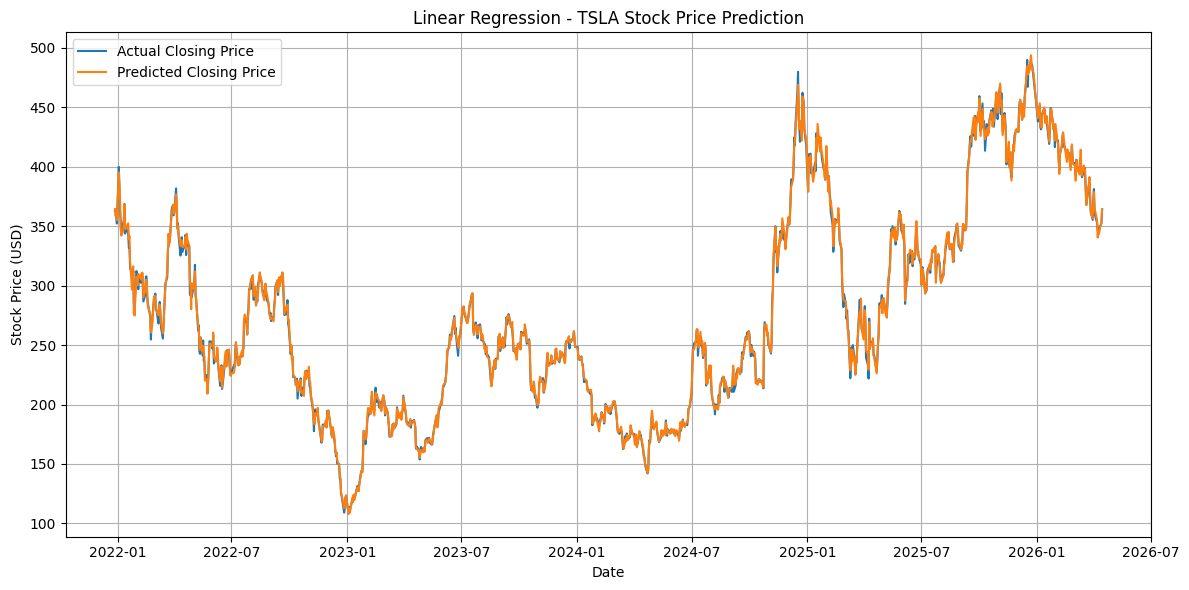

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = yf.download("TSLA", start="2012-01-01")

df = df[['Open', 'High', 'Low', 'Volume', 'Close']]

df.dropna(inplace=True)


X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance (TSLA)")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label="Actual Closing Price")
plt.plot(y_test.index, y_pred, label="Predicted Closing Price")

plt.title("Linear Regression - TSLA Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

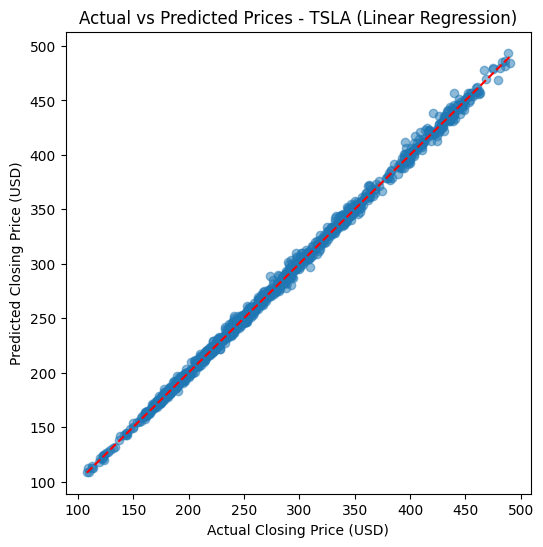

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Closing Price (USD)")
plt.ylabel("Predicted Closing Price (USD)")
plt.title("Actual vs Predicted Prices - TSLA (Linear Regression)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

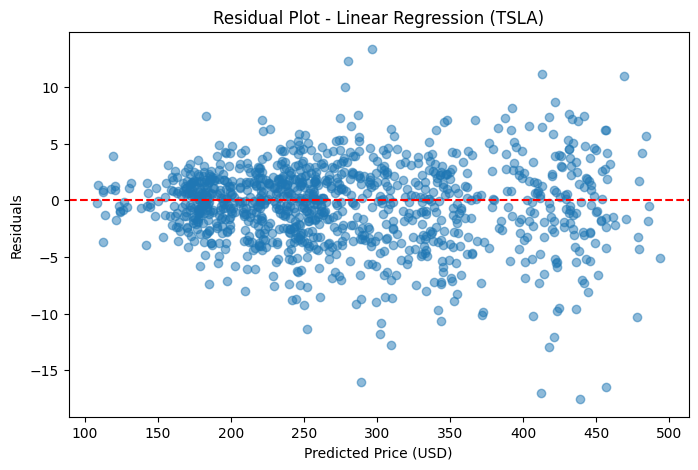

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression (TSLA)")
plt.show()

In [ ]:
mse = rmse**2
print("MSE:", mse)

MSE: 13.17667686520809
